---
# LAB 8: Logistic Regression
##Accuracy, Precision, Recall, Confusion Matrix, ROC Curve

### Logistic Regression on Synthetic Data




Accuracy:  0.98
Precision: 0.97
Recall:    1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       0.97      1.00      0.99        38

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60

Confusion Matrix:
 [[21  1]
 [ 0 38]]


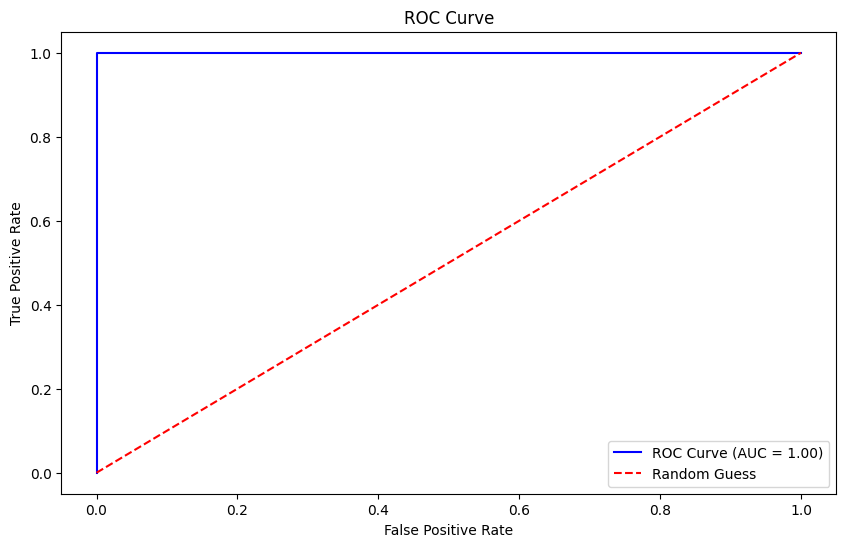

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc, classification_report
)

np.random.seed(42)
X = np.random.rand(200, 2) * 10
y = (4 * X[:, 0] - 3 * X[:, 1] + np.random.randn(200) > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Logistic Regression on Titanic Dataset

> Upload `train.csv` (Titanic) to your Google Drive and update the path below.

In [2]:
import seaborn as sns
%matplotlib inline

# from google.colab import drive
# drive.mount('/content/drive')
# train = pd.read_csv('/content/drive/MyDrive/foundation of data science/Practicals/train.csv')

# Load Titanic from seaborn as a substitute (similar structure)
train = sns.load_dataset('titanic').rename(columns={
    'survived': 'Survived', 'pclass': 'Pclass', 'sex': 'Sex',
    'age': 'Age', 'sibsp': 'SibSp', 'parch': 'Parch',
    'fare': 'Fare', 'embarked': 'Embarked'
})[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

train.head()

# Impute missing ages based on Pclass
def impute_age(row):
    if pd.isnull(row['Age']):
        if row['Pclass'] == 1:
            return 37
        elif row['Pclass'] == 2:
            return 29
        else:
            return 24
    return row['Age']

train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)
train.dropna(inplace=True)

sex = pd.get_dummies(train['Sex'], drop_first=True).astype(int)
embark = pd.get_dummies(train['Embarked'], drop_first=True).astype(int)
train = pd.concat([train, sex, embark], axis=1)
train.drop(['Sex', 'Embarked'], axis=1, inplace=True)

X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101)

logmodel = LogisticRegression(max_iter=500)
logmodel.fit(X_train, y_train)
predictions = logmodel.predict(X_test)

print(classification_report(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       163
           1       0.85      0.69      0.76       104

    accuracy                           0.83       267
   macro avg       0.84      0.81      0.82       267
weighted avg       0.83      0.83      0.83       267

Confusion Matrix:
 [[150  13]
 [ 32  72]]
